<a href="https://colab.research.google.com/github/Juanca25-10/Laboratorios_Collab_Repo/blob/main/Laboratorio_12_JuanCa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HERRAMIENTAS A UTILIZAR:


**PERPLEXITY:**

https://www.perplexity.ai/

**GITHUB:**
https://github.com/




Prompt 1: Crea un codigo python donde cargarás el dataset Diabetes de scikit-learn, que contiene
variables relacionadas con la salud y una variable de salida (target) que mide el nivel de
progreso de la enfermedad. Los datos serán organizados en un DataFrame para
facilitar el manejo.
2. Tareas:
Importar las librerías necesarias.
Cargar los datos utilizando load_diabetes y convertirlos a un DataFrame con
pandas.
Mostrar las primeras filas del DataFrame para explorar los datos

In [3]:
# Importar las librerías necesarias
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar los datos utilizando load_diabetes
diabetes = load_diabetes()

# Convertir a DataFrame de pandas
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target  # Variable de salida: progreso de la enfermedad

# Mostrar las primeras filas del DataFrame
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Prompt 2: Crea un codigo python pero En esta sección, aplicarás un modelo de regresión lineal para predecir los
valores del target (progresión de la enfermedad) en función del índice de masa
corporal (BMI), una de las variables predictoras.
2. Tareas:
Laboratorio 12
Dividir los datos en conjuntos de entrenamiento y prueba usando
train_test_split.
Entrenar un modelo de regresión lineal con la variable BMI como predictora.
Evaluar el modelo utilizando el error cuadrático medio (MSE) como métrica.

In [4]:
# Importar librerías necesarias (asumiendo df ya cargado del paso anterior)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd  # Si no está cargado

# Cargar df si no está disponible (del paso anterior)
# from sklearn.datasets import load_diabetes
# diabetes = load_diabetes()
# df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# df['target'] = diabetes.target

# Preparar datos: BMI como predictor (X), target como salida (y)
X = df[['bmi']].values  # Variable predictora: índice de masa corporal
y = df['target'].values  # Variable objetivo

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Predecir en conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar con Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Error Cuadrático Medio (MSE): {mse}')

Error Cuadrático Medio (MSE): 4061.8259284949268


Prompt 3: Crea un codigo python donde Aplicarás un modelo de regresión logística para clasificar si el valor del
target es mayor que 140. Esto convierte el problema en un problema de clasificación
binaria.
2. Tareas:
Convertir la variable dependiente (target) en binaria.
Dividir los datos en conjuntos de entrenamiento y prueba.
Entrenar un modelo de regresión logística y evaluar su precisión.

In [5]:
# Importar librerías necesarias (asumiendo df del paso anterior)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Convertir target a binaria: 1 si >140 (alta progresión), 0 si <=140
df['target_binary'] = np.where(df['target'] > 140, 1, 0)

# Preparar datos: todas las features como predictoras (X), target binario (y)
X = df.drop(['target', 'target_binary'], axis=1).values
y = df['target_binary'].values

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo de regresión logística
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predecir en conjunto de prueba y evaluar precisión
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.4f}')

Precisión del modelo: 0.7416


Prompt 4: crea un codigo python donde Entrenarás un árbol de decisión para clasificar si el valor del target es
mayor que 140, y evaluarás su precisión sobre el conjunto de prueba.
2. Tareas:
Entrenar un modelo de árbol de decisión.
Realizar predicciones sobre el conjunto de prueba.
Evaluar el modelo utilizando la precisión.

In [6]:
# Importar librerías necesarias (continuando con df del paso anterior)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Preparar datos (ya con target_binary creado)
X = df.drop(['target', 'target_binary'], axis=1).values
y = df['target_binary'].values

# Dividir en entrenamiento y prueba (misma división que antes para comparar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo de árbol de decisión
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # Limitar profundidad para evitar sobreajuste
tree_model.fit(X_train, y_train)

# Realizar predicciones sobre conjunto de prueba
y_pred_tree = tree_model.predict(X_test)

# Evaluar precisión del modelo
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print(f'Precisión del Árbol de Decisión: {tree_accuracy:.4f}')

Precisión del Árbol de Decisión: 0.7303


Prompt 5: Crea un codigo python donde Implementarás un Random Forest con múltiples árboles de decisión para
mejorar la robustez y precisión del modelo.
2. Tareas:
Entrenar un modelo de Random Forest con 100 árboles.
Realizar predicciones y evaluar la precisión del modelo.

In [7]:
# Importar librerías necesarias (continuando con df del laboratorio)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Preparar datos (ya con target_binary del paso anterior)
X = df.drop(['target', 'target_binary'], axis=1).values
y = df['target_binary'].values

# Dividir datos (misma división para comparar modelos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar Random Forest con 100 árboles
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Realizar predicciones sobre conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar precisión del modelo
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Precisión del Random Forest (100 árboles): {rf_accuracy:.4f}')

Precisión del Random Forest (100 árboles): 0.7303


Prompt 6:  Crea un codigo python donde Usarás el modelo ARIMA (AutoRegressive Integrated Moving Average)
para analizar una serie temporal y realizar predicciones. ARIMA es comúnmente usado
para modelar y predecir datos de series temporales.
2. Tareas:
Crear una serie temporal simulada.
Ajustar un modelo ARIMA y realizar predicciones de los valores futuros.

In [8]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# 1. Crear serie temporal simulada (100 puntos con tendencia + ruido + estacionalidad)
np.random.seed(42)
n_points = 100
time_index = pd.date_range(start='2020-01-01', periods=n_points, freq='M')

# Componentes: tendencia + estacionalidad + ruido
trend = 0.5 * np.arange(n_points)
seasonal = 10 * np.sin(2 * np.pi * np.arange(n_points) / 12)
noise = np.random.normal(0, 2, n_points)

# Serie temporal simulada
data = trend + seasonal + noise
ts = pd.Series(data, index=time_index)

# 2. Ajustar modelo ARIMA(2,1,2)
model = ARIMA(ts, order=(2,1,2))  # p=2 (AR), d=1 (diferenciación), q=2 (MA)
model_fit = model.fit()

# 3. Realizar predicciones para 12 meses futuros
forecast = model_fit.forecast(steps=12)
forecast_ci = model_fit.get_forecast(steps=12).conf_int()

# Mostrar resumen del modelo
print(model_fit.summary())
print(f'\nPredicciones para 12 meses futuros:\n{forecast}')

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -241.748
Date:                Wed, 08 Apr 2026   AIC                            493.497
Time:                        01:41:34   BIC                            506.472
Sample:                    01-31-2020   HQIC                           498.747
                         - 04-30-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7310      0.006    299.019      0.000       1.720       1.742
ar.L2         -1.0000      0.000  -3985.042      0.000      -1.000      -1.000
ma.L1         -1.7300      0.134    -12.928      0.0

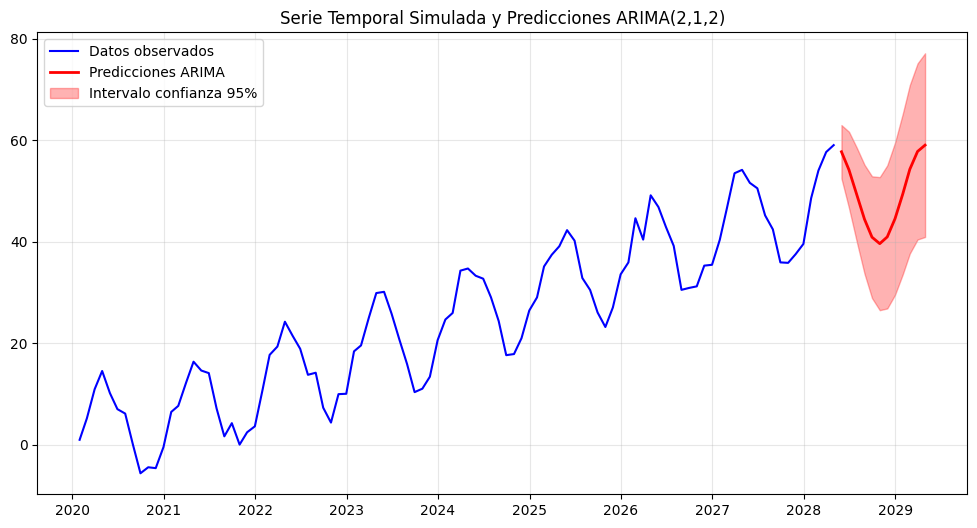

In [9]:
# Gráfico completo
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts, label='Datos observados', color='blue')
plt.plot(forecast.index, forecast, label='Predicciones ARIMA', color='red', linewidth=2)
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                 color='red', alpha=0.3, label='Intervalo confianza 95%')
plt.title('Serie Temporal Simulada y Predicciones ARIMA(2,1,2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Prompt 7:  Crea un codigo python donde descompondrás una serie temporal en sus componentes
principales: tendencia, estacionalidad y residuos.
2. Tareas:
 Descomponer la serie temporal simulada utilizando la función
seasonal_decompose.
Visualizar los componentes de la serie descompuesta.

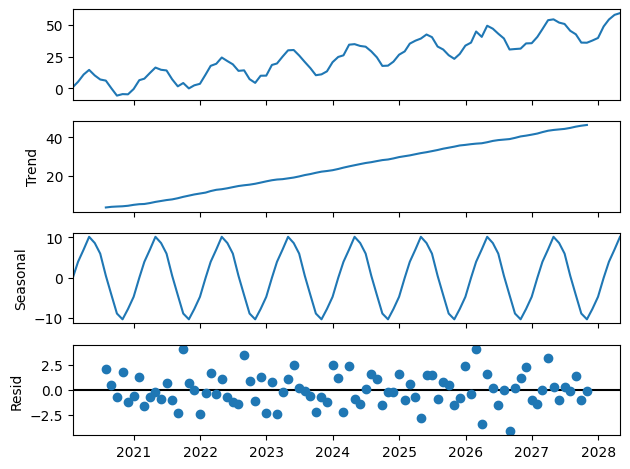

<Figure size 1200x800 with 0 Axes>

In [10]:
# Importar librerías necesarias (continuando con la serie 'ts' del Prompt 6)
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# 1. Descomponer la serie temporal (modelo aditivo por tener tendencia creciente)
decomposition = seasonal_decompose(ts, model='additive', period=12)

# 2. Visualizar los componentes de la serie descompuesta
decomposition.plot()

# Configurar el gráfico
plt.figure(figsize=(12, 8))
plt.suptitle('Descomposición de la Serie Temporal Simulada', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Mostrar componentes numéricamente